# Student name: Gabriel Espinoza Rojas

# Student ID: 22176691

## Please do not add further imports. If you think an import is missing, please contact your moderator.

The notebook provides empty cells for your answer to give you guidance on the answer expected from you. You may add cells, but please note this may mean you go beyond what is expected from you and, if this results in unnecessary/unrelated content being added, may reduce your grade.

In [188]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.inspection import DecisionBoundaryDisplay

# Task 1
## Task 1 Code

These functions are provided to assist you in generating insightful plots

In [242]:
def plot_decision_boundary(estimator, X, y, transformation, axis = None):
    ''' Plots the decision boundary for an estimator using the data transformation provided
    estimator: sklearn estimator object
    X: two-dimensional original feature set
    y: 1 dimensional original labels
    transformation: list defining the transformation to be applied to the features
    '''

    feature_1, feature_2 = np.meshgrid(
        np.linspace(X[:, 0].min(), X[:, 0].max(),num=200),
        np.linspace(X[:, 1].min(), X[:, 1].max(),num=200)
    )
    grid = np.vstack([feature_1.ravel(), feature_2.ravel()]).T
    X_trans_nobias = np.array([transformation(x1,x2) for x1,x2 in grid])
    y_pred = np.reshape(estimator.predict(X_trans_nobias), feature_1.shape)
    display = DecisionBoundaryDisplay(
        xx0=feature_1, xx1=feature_2, response=y_pred
    )
    if axis == None:
        display.plot()
        axis = display.ax_
    else:
        display.plot(ax = axis)
    axis.scatter(
        X[:, 0], X[:, 1], c=y, edgecolor="black"
    )
    axis.set_aspect(1)


## Task 1 Instructions
1. Train scikit-learn’s Logistic Regression algorithm using the Et2_Task1_Training.csv dataset provided in the repository without adding extra features to those provided and estimate the performance of your model on the training data. You do not need to preprocess (e.g. standardise) the data.
2. Test the performance of your model using the Et2_Task1_Test.csv dataset.
3. Plot the data in a scatter plot and plot the decision boundary in this same plot. Make separate plots:
    - one using the  provided function (plot_decision_boundary)
    - one using an equation for the decision boundary derived from the logistic regression parameters found after training.
   Create these plots for the training and test data. It may be useful to create subplots with plots for training and test data in one row for ease of comparison of in-sample and out-of-sample performance. 
4. Try two different hand-crafted (i.e. no need to use functions to create the transformations) polynomial transformations:
    1. one with a transformation resulting in (again) two features and one with a transformation resulting in more than two features and clear overfitting.
    2. Record the training and test errors for both models
    3. Create the same plots you created in step 3 where this is possible. 
5. Answer the following questions (100 words max for each answer):
    1. How do the found values for Ein and Eout for the various models relate to model complexity? Does the theory correspond with your observations?
    2. For this particular dataset, explain how data transformations can lead to (near) linear separability.
    3. Explain how data transformations effect the complexity of your model.

## Task 1 Answer
We suggest to stick to the number of cells provided below.

### 1. Train scikit-learn’s Logistic Regression algorithm using the Et2_Task1_Training.csv dataset provided in the repository without adding extra features to those provided and estimate the performance of your model on the training data. You do not need to preprocess (e.g. standardise) the data.

In [243]:
training_data = np.loadtxt("Et2_Task1_Training.csv", delimiter=",")
X_Task1_Training = training_data[:,0:2]
#X_Task1_Training = np.column_stack((training_data[:,0:1], training_data[:,1:2]))

y_Task1_Training = training_data[:,2]

#estimator = LogisticRegression(random_state=0, fit_intercept=False)
estimator = LogisticRegression(random_state=0)
estimator.fit(X_Task1_Training, y_Task1_Training)

print("estimator.coef_", estimator.coef_)
print("estimator.intercept_:", estimator.intercept_)
print(f"g(x) = {estimator.coef_[0][1]:.2f}*x2 + {estimator.coef_[0][0]:.2f}*x1 + {estimator.intercept_[0]:.2f}")
print(estimator.coef_.shape)

#How to estimate the performance?
estimator.get_params()

# check accuracy // E_in
accuracy = np.mean(estimator.predict(X_Task1_Training) == y_Task1_Training)       
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_in: {1 - accuracy:.4f}")

estimator.coef_ [[ 0.06329325 -0.11713256]]
estimator.intercept_: [0.40638187]
g(x) = -0.12*x2 + 0.06*x1 + 0.41
(1, 2)
Accuracy: 60.00%
E_in: 0.4000


### 2. Test the performance of your model using the Et2_Task1_Test.csv dataset.

In [244]:
testing_data = np.loadtxt("Et2_Task1_Test.csv", delimiter=",")
#X_Task1_Test = np.column_stack((testing_data[:,0:1], testing_data[:,1:2], testing_data[:,2]))
X_Task1_Test = testing_data[:,0:2]
y_Task1_Test = testing_data[:,2]

y_p_Task1_Test = estimator.predict(X_Task1_Test)

# check accuracy // E_out
accuracy = np.mean(y_p_Task1_Test == y_Task1_Test)        
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_out: {1 - accuracy:.4f}")

Accuracy: 50.00%
E_out: 0.5000


### 3. Plot the data in a scatter plot and plot the decision boundary in this same plot. Make separate plots:
    1. one using the  provided function (plot_decision_boundary)
    2. one using an equation for the decision boundary derived from the logistic regression parameters found after training.
   Create these plots for the training and test data. It may be useful to create subplots with plots for training and test data in one row for ease of comparison of in-sample and out-of-sample performance. 

In [245]:
# you may wish to use this cell to define a function for plot number 2 above

def my_plot_decision_boundary(estimator, X, y, transformation, axis):
    ''' Plots the decision boundary for an estimator using the weights and bias found by the estimator 
    estimator: trained sklearn LogisticRegression model
    X: two-dimensional original feature set
    y: 1 dimensional original labels
    transformation: label that defines the transformation to be applied to the features (e.g. 'linear' or 'squares')
    axis: matplotlib axis object to plot on
    '''

    # get the weights and bias from the trained estimator
    w = np.concatenate((estimator.intercept_, estimator.coef_[0]))

    # plot the data points
    axis.scatter(X[:, 0], X[:, 1], c=y, edgecolor="black")
    axis.set_aspect(1)
    
    # check the transformation to be applied to the features and plot the decision boundary accordingly
    if transformation == 'linear':
        # w1*x1 + w2*x2 + b = 0
        x1_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)
        x2_vals = -(w[1] * x1_vals + w[0]) / w[2]
        axis.plot(x1_vals, x2_vals, c='green')
        
    elif transformation == 'squares':
        # w1*x1^2 + w2*x2^2 + b = 0
        x1_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 2000)

        # x2^2 = -(w1*x1^2 + b) / w2
        right_hand_side = -(w[1] * x1_vals**2 + w[0]) / w[2]

        # numerical safety
        #right_hand_side = np.clip(right_hand_side, 0, None)
        safety = right_hand_side >= 0
        
        positive_x2_vals = np.sqrt(right_hand_side[safety])
        negative_x2_vals = -positive_x2_vals

        axis.plot(x1_vals[safety],  positive_x2_vals, c='green')
        axis.plot(x1_vals[safety], negative_x2_vals, c='green')
    else:
        print("Transformation not recognised. No decision boundary plotted.")

plot using function plot_decision_boundary:


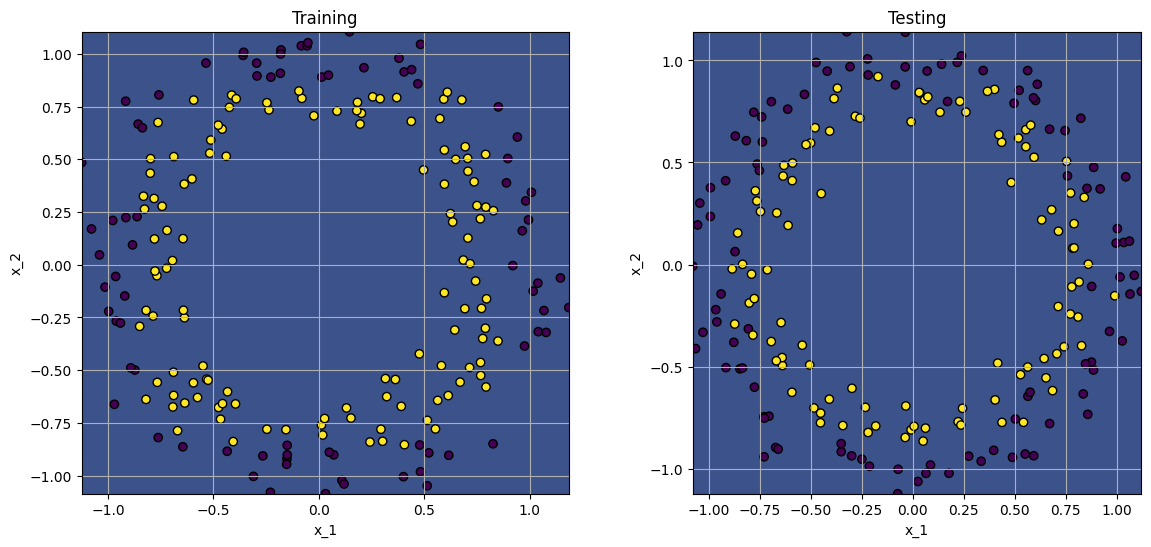

plot using the weights found by LogisticRegression for the decision boundary:


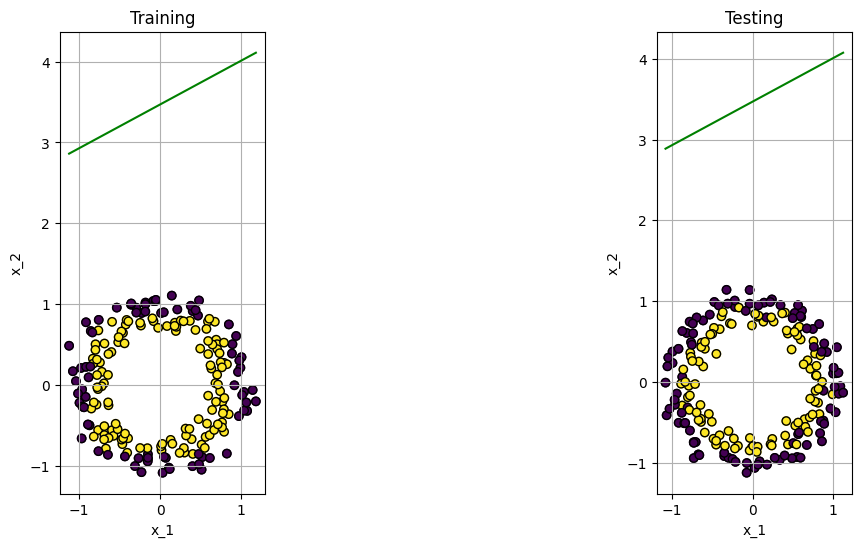

In [246]:
def no_transformation(x1, x2):
     return [x1, x2]


print("plot using function plot_decision_boundary:")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

#Training // E_in // in sample
ax1.set_title(f'Training')
plot_decision_boundary(estimator, X_Task1_Training, y_Task1_Training, no_transformation, ax1)
#ax1.legend(loc="best")
ax1.set_xlabel("x_1")
ax1.set_ylabel("x_2")
ax1.grid()

#Testing // E_out // out of sample
ax2.set_title(f'Testing')
plot_decision_boundary(estimator, X_Task1_Test, y_Task1_Test, no_transformation, ax2)
ax2.set_xlabel("x_1")
ax2.set_ylabel("x_2")
ax2.grid()

plt.show()


print("plot using the weights found by LogisticRegression for the decision boundary:")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.set_title(f'Training')
ax1.scatter(X_Task1_Training[:,0], X_Task1_Training[:,1], c=y_Task1_Training)
my_plot_decision_boundary(estimator, X_Task1_Training, y_Task1_Training, 'linear', ax1)
ax1.set_xlabel("x_1")
ax1.set_ylabel("x_2")
ax1.grid()

ax2.set_title(f'Testing')
ax2.scatter(X_Task1_Test[:,0], X_Task1_Test[:,1], c=y_Task1_Test)
my_plot_decision_boundary(estimator, X_Task1_Test, y_Task1_Test, 'linear', ax2)
ax2.set_xlabel("x_1")
ax2.set_ylabel("x_2")
ax2.grid()
plt.show()



### 4. Try two different hand-crafted (i.e. no need to use functions to create the transformations) polynomial transformations:
    1. one with a transformation resulting in (again) two features and one with a transformation resulting in more than two features and clear overfitting.
    2. Record the training and test errors for both models
    3. Create the same plots you created in step 3 where this is possible. 

#### Transformation 1

estimator.coef_ [[-3.82791572 -4.25574997]]
estimator.intercept_: [3.84941158]
Shape:  (1, 2)
Accuracy: 85.50%
E_in: 0.1450
Accuracy: 87.50%
E_out: 0.1250
Transformation resulting in two features:


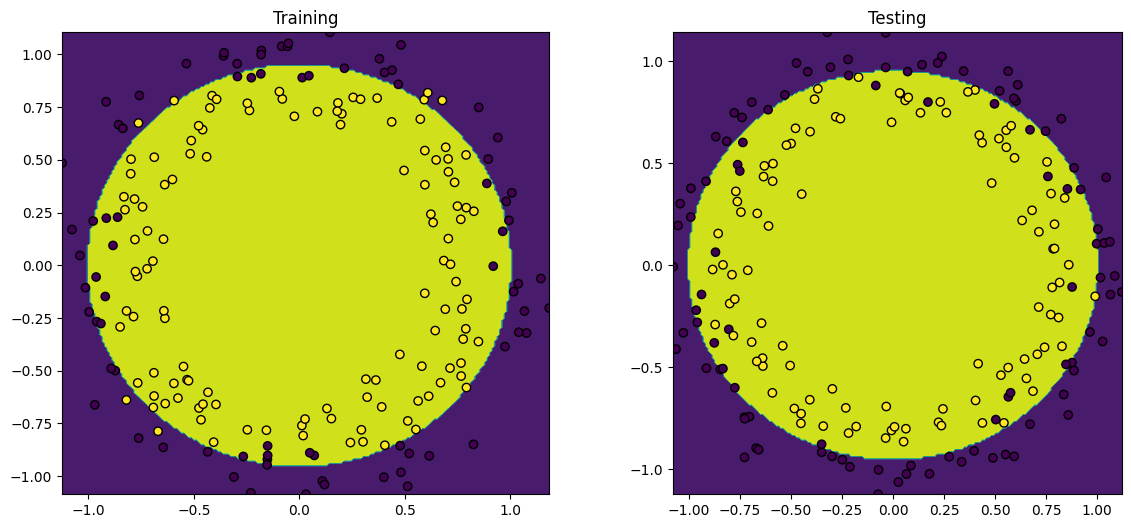

plot using the weights found by LogisticRegression for the decision boundary:


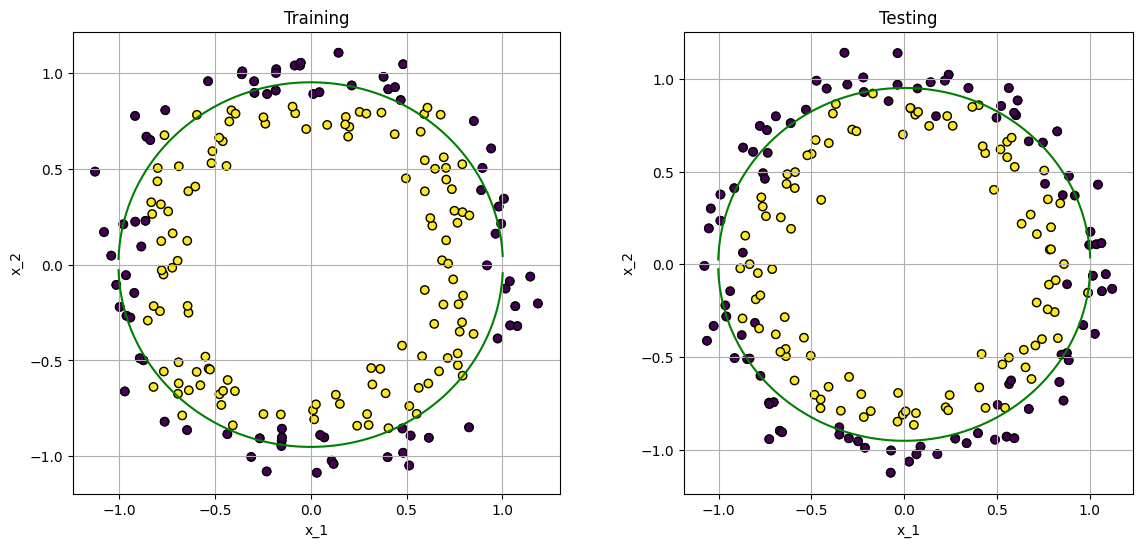

In [247]:
# only two features
def squares(x1, x2):
     return [x1**2, x2**2]

trans1_training_data = np.loadtxt("Et2_Task1_Training.csv", delimiter=",")

#x1^2, x2^2
trans1_X_Task1_Training = np.array([squares(x1, x2) for x1,x2 in trans1_training_data[:,0:2]]) # np.column_stack(( trans1_training_data[:,0:1]**2, trans1_training_data[:,1:2]**2))

trans1_y_Task1_Training = trans1_training_data[:,2]

estimator = LogisticRegression(random_state=0)
estimator.fit(trans1_X_Task1_Training, trans1_y_Task1_Training)

print("estimator.coef_", estimator.coef_)
print("estimator.intercept_:", estimator.intercept_)
print("Shape: ", estimator.coef_.shape)

# check accuracy // E_in
accuracy = np.mean(estimator.predict(trans1_X_Task1_Training) == trans1_y_Task1_Training)       
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_in: {1 - accuracy:.4f}")


trans1_testing_data = np.loadtxt("Et2_Task1_Test.csv", delimiter=",")
#x1^2, x2^2
trans1_X_Task1_Test = np.array([squares(x1, x2) for x1,x2 in trans1_testing_data[:,0:2]]) #np.column_stack(( trans1_testing_data[:,0:1]**2, trans1_testing_data[:,1:2]**2))
trans1_y_Task1_Test = trans1_testing_data[:,2]

trans1_y_p_Task1_Test = estimator.predict(trans1_X_Task1_Test)

# check accuracy // E_out
accuracy = np.mean(trans1_y_p_Task1_Test == trans1_y_Task1_Test)        
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_out: {1 - accuracy:.4f}")

print("Transformation resulting in two features:")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

#Training // E_in // in sample
ax1.set_title(f'Training')
plot_decision_boundary(estimator, X_Task1_Training, y_Task1_Training, squares, ax1)
ax1.grid()

#Testing // E_out // out of sample
ax2.set_title(f'Testing')
plot_decision_boundary(estimator, X_Task1_Test, y_Task1_Test, squares, ax2)
ax1.grid()
plt.show()



print("plot using the weights found by LogisticRegression for the decision boundary:")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.set_title(f'Training')
ax1.scatter(X_Task1_Training[:,0], X_Task1_Training[:,1], c=trans1_y_Task1_Training)
my_plot_decision_boundary(estimator, X_Task1_Training, y_Task1_Training, 'squares', ax1)
ax1.set_xlabel("x_1")
ax1.set_ylabel("x_2")
ax1.grid()

ax2.set_title(f'Testing')
ax2.scatter(X_Task1_Test[:,0], X_Task1_Test[:,1], c=trans1_y_p_Task1_Test)
my_plot_decision_boundary(estimator, X_Task1_Test, y_Task1_Test, 'squares', ax2)
ax2.set_xlabel("x_1")
ax2.set_ylabel("x_2")
ax2.grid()
plt.show()



#### Transformation 2

estimator.coef_ [[-1.84792872 -2.30164951 -0.0350423   0.21437152 -0.04704238 -3.72019473
  -3.83142328]]
estimator.intercept_: [4.36197399]
Shape:  (1, 7)
Accuracy: 93.50%
E_in: 0.0650
Accuracy: 83.50%
E_out: 0.1650
Transformation resulting more than two features and over fitting:


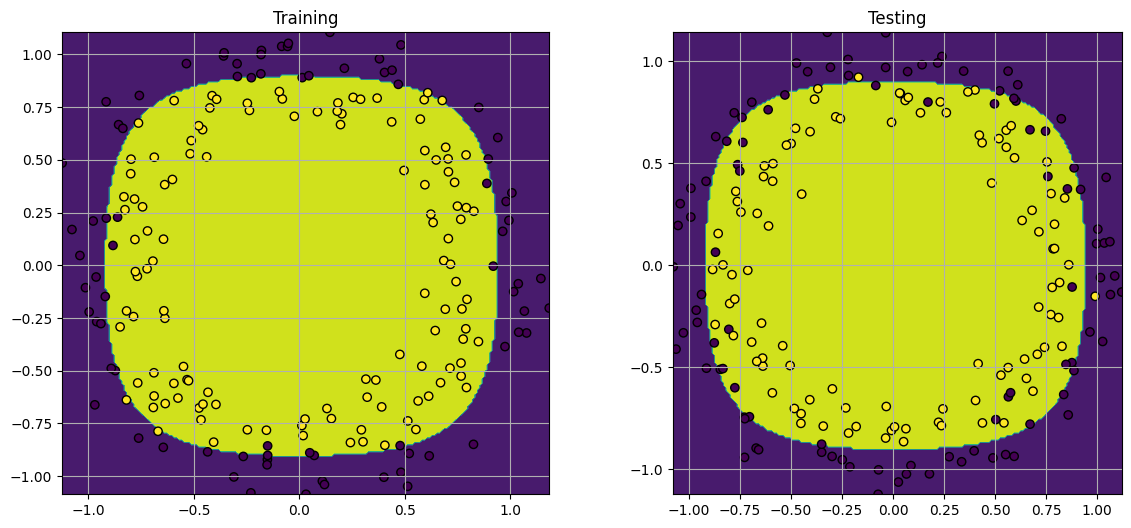

In [248]:
# more than two features and over fitting, E_in is low but E_out is high
def overfit_transformation(x1, x2):
     return [x1**2, x2**2, x1*x2, x1**3, x2**3, x1**4, x2**4]

trans2_training_data = np.loadtxt("Et2_Task1_Training.csv", delimiter=",")

#x1^2, x2^2, x1^3, x2^3, x1^4, x2^4
trans2_X_Task1_Training = np.array([overfit_transformation(x1, x2) for x1,x2 in trans2_training_data[:,0:2]]) #np.column_stack(( trans2_training

trans2_y_Task1_Training = trans2_training_data[:,2]

estimator = LogisticRegression(random_state=0)
estimator.fit(trans2_X_Task1_Training, trans2_y_Task1_Training)

print("estimator.coef_", estimator.coef_)
print("estimator.intercept_:", estimator.intercept_)
print("Shape: ", estimator.coef_.shape)

# check accuracy // E_in
accuracy = np.mean(estimator.predict(trans2_X_Task1_Training) == trans2_y_Task1_Training)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_in: {1 - accuracy:.4f}")



trans2_testing_data = np.loadtxt("Et2_Task1_Test.csv", delimiter=",")
#x1^2, x2^2, x1^3, x2^3, x1^4, x2^4
trans2_X_Task1_Test = np.array([overfit_transformation(x1, x2) for x1,x2 in trans2_testing_data[:,0:2]]) #np.column_stack(( trans2_testing_data[:,0:1]**2,  --- IGNORE ---

trans2_y_Task1_Test = trans2_testing_data[:,2]

trans2_y_p_Task1_Test = estimator.predict(trans2_X_Task1_Test)

# check accuracy // E_out
accuracy = np.mean(trans2_y_p_Task1_Test == trans2_y_Task1_Test)        
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_out: {1 - accuracy:.4f}")

print("Transformation resulting more than two features and over fitting:")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

#Training // E_in // in sample
ax1.set_title(f'Training')
plot_decision_boundary(estimator, X_Task1_Training, y_Task1_Training, overfit_transformation, ax1)
ax1.grid()

#Testing // E_out // out of sample
ax2.set_title(f'Testing')
plot_decision_boundary(estimator, X_Task1_Test, y_Task1_Test, overfit_transformation, ax2)
ax2.grid()
plt.show()


#### Optional cell (for discussion)

estimator.coef_ [[ 0.11394557 -0.09020076  0.09611976 -3.83644154 -4.25380461]]
estimator.intercept_: [3.85308369]
Shape:  (1, 5)
Accuracy: 86.50%
E_in: 0.1350
Accuracy: 87.50%
E_out: 0.1250
Extra, optional transformation resulting in five features:


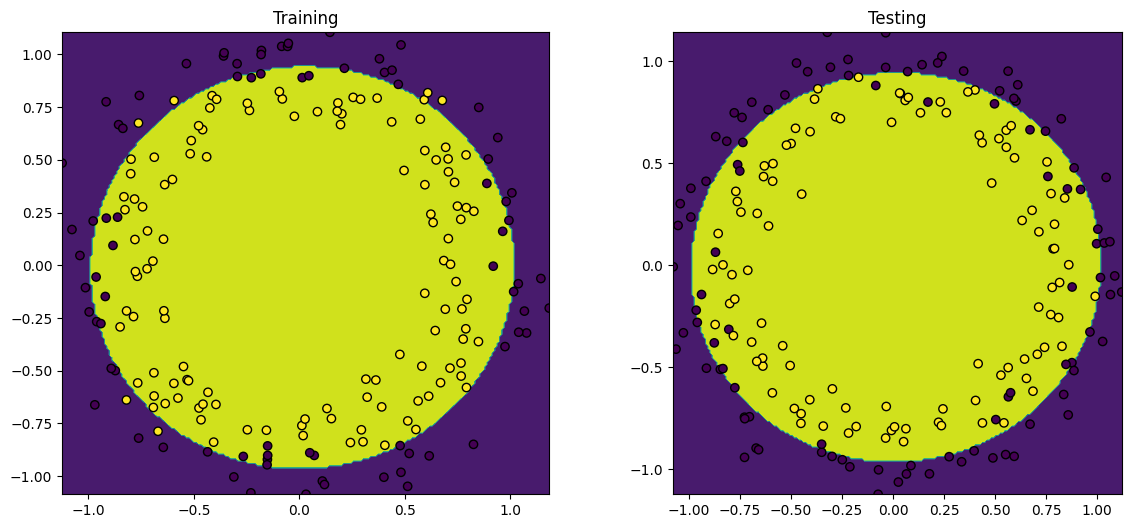

In [249]:
# ***optional cell***
# z = (1, x_1, x_2, x_1*x_2, x_1^2, x_2^2)

def extra_transformation_no_discounts(x1, x2):
     return [x1, x2, x1*x2, x1**2, x2**2]

trans1_training_data = np.loadtxt("Et2_Task1_Training.csv", delimiter=",")

#x1^2, x2^2
extra_X_Task1_Training = np.array([extra_transformation_no_discounts(x1, x2) for x1,x2 in trans1_training_data[:,0:2]]) # np.column_stack(( trans1_training_data[:,0:1]**2, trans1_training_data[:,1:2]**2))

extra_y_Task1_Training = trans1_training_data[:,2]

estimator = LogisticRegression(random_state=0)
estimator.fit(extra_X_Task1_Training, extra_y_Task1_Training)

print("estimator.coef_", estimator.coef_)
print("estimator.intercept_:", estimator.intercept_)
print("Shape: ", estimator.coef_.shape)

# check accuracy // E_in
accuracy = np.mean(estimator.predict(extra_X_Task1_Training) == extra_y_Task1_Training)       
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_in: {1 - accuracy:.4f}")


extra_testing_data = np.loadtxt("Et2_Task1_Test.csv", delimiter=",")
#x1^2, x2^2
extra_X_Task1_Test = np.array([extra_transformation_no_discounts(x1, x2) for x1,x2 in extra_testing_data[:,0:2]]) #np.column_stack(( extra_testing_data[:,0:1]**2, extra_testing_data[:,1:2]**2))
extra_y_Task1_Test = extra_testing_data[:,2]

extra_y_p_Task1_Test = estimator.predict(extra_X_Task1_Test)

# check accuracy // E_out
accuracy = np.mean(extra_y_p_Task1_Test == extra_y_Task1_Test)        
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_out: {1 - accuracy:.4f}")




print("Extra, optional transformation resulting in five features:")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

#Training // E_in // in sample
ax1.set_title(f'Training')
plot_decision_boundary(estimator, extra_X_Task1_Training, extra_y_Task1_Training, extra_transformation_no_discounts, ax1)
ax1.grid()

#Testing // E_out // out of sample
ax2.set_title(f'Testing')
plot_decision_boundary(estimator, extra_X_Task1_Test, extra_y_Task1_Test, extra_transformation_no_discounts, ax2)
#ax1.scatter(X_Task1_Test[:,0], X_Task1_Test[:,1], c=y_Task1_Test)
ax1.grid()
plt.show()

### 5 Answer the following questions (100 words max for each answer): 

<b>1. How do the found values for Ein and Eout for the various models relate to model complexity? Does the theory correspond with your observations?</b>

Model one: The errors aren't great ($E_{in} = 0.40$, $E_{out} = 0.50$) as expected of a model with only linear hypothesis. linear features: $x = (1, x_1, x_2)$. Complexity $d_{VC} = 3$.

Model two: with data snooping and a 2 transformation, we get a significant improvement: $E_{in} = 0.14$ and $E_{out} = 0.12$. Transformation: $z = (1, x_1^2, x_2^2)$. Complexity $d_{VC} = 3$.
(DOUBLE CHECK THIS!!)

Model three: $z = (1, x_1^2, x_2^2, x_1^3, x_2^3, x_1^4, x_2^4)$ ( $d_{VC} = 7$). It overfits ($E_{in} = 0.06$) significantly smaller than ($E_{out} = 0.16$). With the extra features, we captured coincidental trends in our data.

<b>2. For this particular dataset, explain how data transformations can lead to (near) linear separability.</b>

With some data snooping, it appears that a good decision boundary would be a circle. Linear features $(1, x_1, x_2)$ can only come up with straight lines. By applying a polynomial transformation $z = (1, x_1^2, x_2^2)$, the results show a massive improvement (50% to 87.50% accuracy). And we get away with a <i>'discount'</i> since the full space from the previous transformation would look like $z = (1, x_1, x_2, x_1*x_2, x_1^2, x_2^2)$ but as my last and optional plot shows, the results are the same despite of the complexity gap ($d_{VC} = 3$ versus $d_{VC} = 6$).

<b>3. Explain how data transformations effect the complexity of your model.</b>

Transformations often increase the complexity of the model. The expectation is that applying them will give better results. Task 2 takes us through transformations that not necessarily follow this. With some data snooping, we kept the original complexity ($d_{VC} = 3$), but with significantly better results. When the goal was overfitting, a complex model ($d_{VC} = 7$) was outperformed by a simpler model ($d_{VC} = 3$). To make sure $z = (1, x_1^2, x_2^2)$ was not missing anything along the way, I plotted $z = (1, x_1, x_2, x_1*x_2, x_1^2, x_2^2)$ ($d_{VC} = 6$) and the statement still holds.



# Task 2
## Task 2 Code

In [254]:
def weights(X,y):
    '''Returns the weight vector associated with the regression line that best describes the data X,y in an MSE fashion '''
    # add bias 1 to inputs X
    X = np.concatenate((np.ones((X.shape[0],1)),X.reshape(X.shape[0],X.shape[1])),axis=1)
    # Calculation of weights using pseudo-inverse.
    return np.linalg.inv((X.T.dot(X))).dot(X.T).dot(y)

In [255]:
def linreg_predict(w,X):
    ''' Returns a prediction y for data point X for a linear regression described by weights w '''
    # add bias 1 to inputs X
    X = np.concatenate((np.ones((X.shape[0],1)),X.reshape(X.shape[0],X.shape[1])),axis=1)
    
    # Calculation of outputs given weights and data (X). 
    out=[]
    for x in X:
        out.append(w.T.dot(x))
    return np.array(out)

In [256]:
def calc_error(w,X,y):
    # Calculate the error as the mean squared error
    pred = linreg_predict(w,X)
    return (pred-np.array(y)).dot(pred-np.array(y))/len(X)

In [257]:
def transPoly(X, power):
    # Extend the data in X with dimensions [N,1] with powers of the feature up to 'power' 
    X=X.reshape(-1,1)
    extra=[]
    for x in X[:,0]:
        row=[]
        for p in range(2,power+1):
            row.append(x**p)
        extra.append(row)
    return np.concatenate((X.reshape(len(X),1),np.array(extra)),1)

Below snippet may be of use in this task

```python
error_in = []
error_val = []
repeats = XXX
power_range = # it is up to you to decide on a suitable range

for power in power_range:
    e_in=0
    e_val=0
    for r in range(repeats):
        X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=XX) # choose a suitable train_size
        X_train_trans = # implement your data transformation
        X_val_trans = # implement your data transformation
        w = weights(X_train_trans,y_train)
        e_in += calc_error(w,X_train_trans,y_train)
        e_val+= calc_error(w,X_val_trans,y_val)
    error_in.append(e_in/repeats)
    error_val.append(e_val/repeats)
```

## Task 2 Instructions
1. Load the dataset provided in Et2_Task2.csv
2. Use the provided linear regression algorithm to obtain the best possible fit to the data set.
    - With the knowledge that the data source is a noisy polynomial with the highest order no lower than 5 and no higher than 10, use a structured approach to try different feature transformations using the provided transformation functions.
    - For statistically reliable results, it is important to repeat the experiment a number of times. 
    - In each experiment, split the dataset provided in Et2_Task2.csv into a in-sample (training) and an 'out of sample' dataset (decide on a suitable ratio).
    - Record the performance on in-sample data and on 'out-of-sample' data.
    - Create a plot of the validation error versus the complexity of the model.
3. Use the results to decide on the data transformation (max polynomial power) that yields the best results.
4. Answer the following questions (100 words max for each answer):
    - How does the plot of Ein and Eout versus degree of the used polynomial data transformation relate to model complexity
    - Using the graph, explain how you chose the optimal model complexity.
    - How can the choice of transformation that yielded the best results be explained in terms of sample complexity?

## Task 2 Answer
We suggest to stick to the number of cells provided below.

### 1. Load the dataset provided in Et2_Task2.csv

(100,)
(100,)


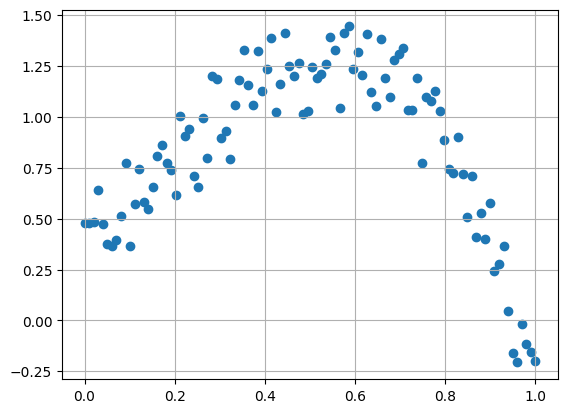

In [253]:
data_task2 = np.loadtxt("Et2_Task2.csv", delimiter=",")
X_Task2 = data_task2[:,0]
y_Task2 = data_task2[:,1]

print(np.shape(X_Task2))
print(np.shape(y_Task2))
plt.scatter(X_Task2, y_Task2)
plt.grid()

### 2. Use the provided linear regression algorithm to obtain the best possible fit to the training data set.
- With the knowledge that the data source is a noisy polynomial with the highest order no lower than 5 and no higher than 10, use a structured approach to try different feature transformations using the provided transformation functions.
- For statistically reliable results, it is important to repeat the experiment a number of times.
- In each experiment, split the dataset provided in Et2_Task2.csv into a in-sample (training) and an 'out of sample' dataset (decide on a suitable ratio).
- Record the performance on in-sample data and on 'out-of-sample' data.
- Create a plot of the validation error versus the complexity of the model.

In [258]:
error_in = []
error_val = []
repeats = 1000
"""the data source has 6 to 11 features (counting the bias)"""
#QUESTION: How to decide on a suitable range? I data snooped and believe that the best shape
# to model the that would be an even number of at least 2 or higher.
# the model is chasing a unknown target function that might or not be in that range
# but anything above 10 is an overkill. 
power_range = [10,9,8,7,6,5,4,3,2,1]

for power in power_range:
    e_in=0
    e_val=0
    for r in range(repeats):
        # split data into 70% training and 30% testing sets
        X_train, X_val, y_train, y_val = train_test_split(X_Task2, y_Task2, train_size=0.7) # choose a suitable train_size
        X_train_trans = transPoly(X_train, power) # implement your data transformation
        X_val_trans =  transPoly(X_val, power) # implement your data transformation
        w = weights(X_train_trans,y_train)
        e_in += calc_error(w,X_train_trans,y_train)
        e_val+= calc_error(w,X_val_trans,y_val)
    error_in.append(e_in/repeats)
    error_val.append(e_val/repeats)

print(error_in)
print(error_val)

[np.float64(0.015472545111936296), np.float64(0.015799952415143124), np.float64(0.01580971907693083), np.float64(0.016006460598393408), np.float64(0.016044006641616176), np.float64(0.01676463063792002), np.float64(0.016910402056190797), np.float64(0.01698852056773129), np.float64(0.028545915318543513), np.float64(0.16555409625840017)]
[np.float64(0.02486783463014862), np.float64(0.02184679503250181), np.float64(0.02040176695575874), np.float64(0.019767959539550118), np.float64(0.019468186836458463), np.float64(0.019969374855005315), np.float64(0.019318666693883695), np.float64(0.018781970632348714), np.float64(0.03148664469513371), np.float64(0.17612208249152086)]


### 3. Use the results to decide on the data transformation (max polynomial power) that yields the best results.

In [277]:
for index, power in enumerate(power_range):
    print(f"For order {power}, E_in: {error_in[index]:.4f} and E_out: {error_val[index]:.4f}, Delta: {error_val[index] - error_in[index]:.4f}")

argmin = power_range[error_val.index(min(error_val))]
print(f"** polynomial of order {argmin} as the smaller delta between E_in and E_out **")

For order 10, E_in: 0.0155 and E_out: 0.0249, Delta: 0.0094
For order 9, E_in: 0.0158 and E_out: 0.0218, Delta: 0.0060
For order 8, E_in: 0.0158 and E_out: 0.0204, Delta: 0.0046
For order 7, E_in: 0.0160 and E_out: 0.0198, Delta: 0.0038
For order 6, E_in: 0.0160 and E_out: 0.0195, Delta: 0.0034
For order 5, E_in: 0.0168 and E_out: 0.0200, Delta: 0.0032
For order 4, E_in: 0.0169 and E_out: 0.0193, Delta: 0.0024
For order 3, E_in: 0.0170 and E_out: 0.0188, Delta: 0.0018
For order 2, E_in: 0.0285 and E_out: 0.0315, Delta: 0.0029
For order 1, E_in: 0.1656 and E_out: 0.1761, Delta: 0.0106
** polynomial of order 3 as the smaller delta between E_in and E_out **


Which power provides better results? [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]


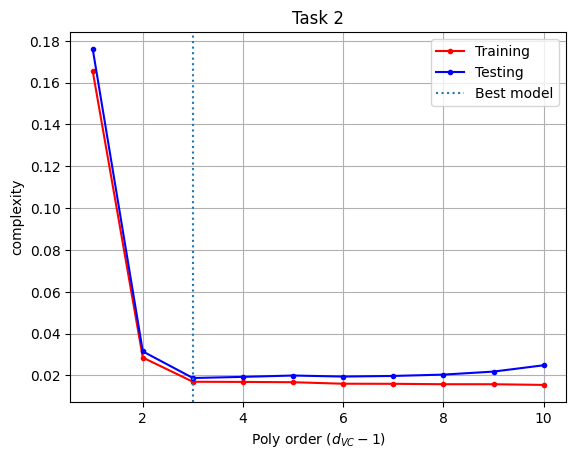

In [260]:
print("Which power provides better results?", power_range)

complexity_for_plotting = np.array(power_range)

plt.figure()
plt.title("Task 2")

plt.xlabel('Poly order ($d_{VC} - 1$)')
plt.ylabel("complexity")

plt.plot(complexity_for_plotting, error_in, c='red', marker='.', label="Training")
plt.plot(complexity_for_plotting, error_val, c='blue', marker='.', label="Testing")
plt.axvline(x=argmin, linestyle=':', label=f"Best model")

plt.legend(loc="best")
plt.grid()

<!--The amount of data dictated the complexity we can afford-->

### 4. Answer the following questions (100 words max for each answer):

<b>1. How does the plot of $E_{in}$ and $E_{out}$ versus degree of the used polynomial data transformation relate to model complexity</b>

The VC bound increases with the order of the polynomial (d = poly order + 1). It shows that as complexity increases, $E_{in}$ gets closer to zero, the model captures more and more the behaviour of the in-sample data. For $E_{out}$ the story is different, at first it generalises poorly, then there's a sweet spot where both $E_{in}$ and $E_{out}$ are at their conjoined lowest, and then the out-of-sample error will go up, as the model starts to overfit (the data set is small).

<b>2. Using the graph, explain how you chose the optimal model complexity.</b>

Where the difference between $E_{in}$ and $E_{out}$ is minimal, that's where the optimal model complexity has been found. Considering the data set size (100) and the split between training and testing (70%/30%), realistically, anything above d = 7 was going to go out of our rule of thumb of 'we want 10 samples per feature' and overfit.

<b>3. How can the choice of transformation that yielded the best results be explained in terms of sample complexity?</b>

This task contains a hint that I believe can be misleading (for educational purposes). Despite of the original data coming from a noisy polynomial of at least 6 terms (if you consider the bias), the best results we get come from a model with less terms ($3 + 1 = 4$) than the source function. This is because <u>the size of our data set tells what complexity we can afford</u>. This goes back to your rule of thumb for our data set.




# Task 3
## Task 3 Code

Below is an implementation of linear regression with regularization

In [ ]:
def weights_reg(X,y,l):
    '''Returns the weight vector associated with the regression line that best describes the data X,y in an MSE fashion 
    including a weight regularisation penalty term controlled using l '''
    # add bias 1 to inputs X
    X = np.concatenate((np.ones((X.shape[0],1)),X.reshape(X.shape[0],X.shape[1])),axis=1)
    n = len(X)
    m=X.T.dot(X)
    return np.linalg.inv(m+l*np.identity(m.shape[0])).dot(X.T).dot(y)

This code snippet may be useful to keep track of Ein and Eout for various regulariser parameters:

```python
ein=[]
eout=[]
weights=[]
lambdas = # choose a suitable range of lambdas here
X_trans = transPoly(X,50)
# random_state fixed to get reproducible (and 'good'! :-)) results
X_train, X_test, y_train, y_test = train_test_split(X_trans, y, train_size=0.5, random_state =5)
for l in lambdas:    
    w = weights_reg(X_train,y_train,l)
    ein.append(calc_error(w,X_train,y_train))
    eout.append(calc_error(w,X_test,y_test))
    weights.append(w)
    
plt.plot(lambdas,eout)
plt.show()
  ```

## Task 3 Instructions

1. Load the dataset provided in Et2_Task3.csv
2. Use the provide function transPoly to obtain a feature vector of the original feature raised up to the power of 50
3. Use the provided code snippet and weights_reg function to perform linear regression on the data and find the optimum regularization parameter, l. In order to do so, you will need to decide on a suitable list of l values. Pick at most 1000 values!
4. Once you have found the optimal l, compare the Eout obtained with this l with the Eout obtained without regularization. You should see an impressive improvement!
5. Provide the following plots:
    - A plot showing model performance vs l on the domain [0,1]
    - A plot with three sub-plots containing an overfitted model, a model with the optimal l, and an underfitted model. In each plot, you should plot the data points in addition to the final hypothesis. Choose values for l that clearly demonstrate over- and underfitting.
6. Answer the following questions (100 words max for each answer):
    1. Interpret the information in the requested figures under point 5.
    2. Explain the strategy chosen to decide on the optimum amount of regularisation. In your answer discuss how you refined the hyper parameter search space while looking for the optimal l.
    3. Explain the effect of the term l*np.identity(m.shape[0]) in the pseudo-inverse.

## Task 3 Answer
We suggest to stick to the number of cells provided below.

### 1. Load the dataset provided in Et2_Task3.csv

(10000, 1)
(10000,)


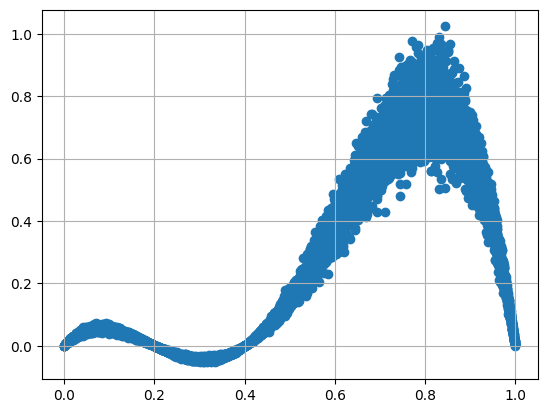

In [ ]:
data_task3 = np.loadtxt("Et2_Task3.csv", delimiter=",")
X_Task3 = data_task3[:,0:1]
y_Task3 = data_task3[:,1]

#X_Task3 = data_task3[:,0]
#y_Task3 = data_task3[:,1]

print(np.shape(X_Task3))
print(np.shape(y_Task3))
plt.scatter(X_Task3, y_Task3)
plt.grid()

### 2. Use the provide function transPoly to obtain a feature vector of the original feature raised up to the power of 50

In [278]:
X_trans = transPoly(X_Task3, 50)

### 3. Use the provided code snippet and weights_reg function to perform linear regression on the data and find the optimum regularization parameter, l.
       - In order to do so, you will need to decide on a suitable list of l values. Pick at most 1000 values!

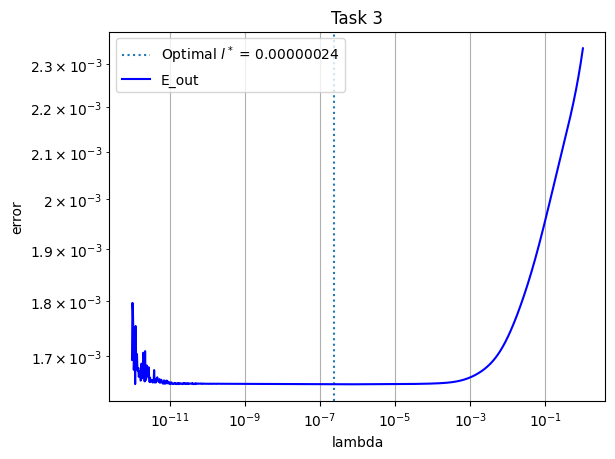

In [ ]:
ein=[]
eout=[]
weights=[]

# don't use zero
# L2 Ridge regularisation
# Generate 1000 points logarithmically spaced from 10^-12 to 10^0 (1.0)
lambdas = np.logspace(-12, 0, 1000)

# random_state fixed to get reproducible (and 'good'! :-)) results
X_train, X_test, y_train, y_test = train_test_split(X_trans, y_Task3, train_size=0.8, random_state =5)
for l in lambdas:    
    w = weights_reg(X_train, y_train, l)
    ein.append(calc_error(w, X_train, y_train))
    eout.append(calc_error(w, X_test, y_test))
    weights.append(w)
    
optimal_lambda = lambdas[np.argmin(eout)]
plt.axvline(x=optimal_lambda, linestyle=':', label=f'Optimal $l^*$ = {optimal_lambda:.8f}')
plt.plot(lambdas, eout, c='blue', label='E_out')
plt.legend(loc="best")
plt.title("Task 3")
plt.xlabel("lambda")
plt.ylabel("error")
plt.yscale("log")
plt.xscale("log")
plt.grid()
plt.show() 

In [268]:
# is zero in the lambda range?
print(f"Is zero in the lambda range? {'Yes' if 0 in lambdas else 'No'}")

Is zero in the lambda range? No


### 4. Once you have found the optimal l, compare the Eout obtained with this l with the Eout obtained without regularization. You should see an impressive improvement!

In [269]:
#borrowed from E-tivity 1
def linreg_predict(w,X):
    # add bias 1 to inputs X
    X = np.concatenate((np.ones((X.shape[0],1)),X.reshape(X.shape[0],X.shape[1])),axis=1)
    
    # Calculation of outputs given weights and data (X). 
    out=[]
    for x in X:
        out.append(w.T.dot(x))
    return np.array(out)

Optimal lambda: 2.406475150015422e-07
Error with no regularisation: 242.3733765732253
Error with optimal regularisation: 0.0016312763832485007


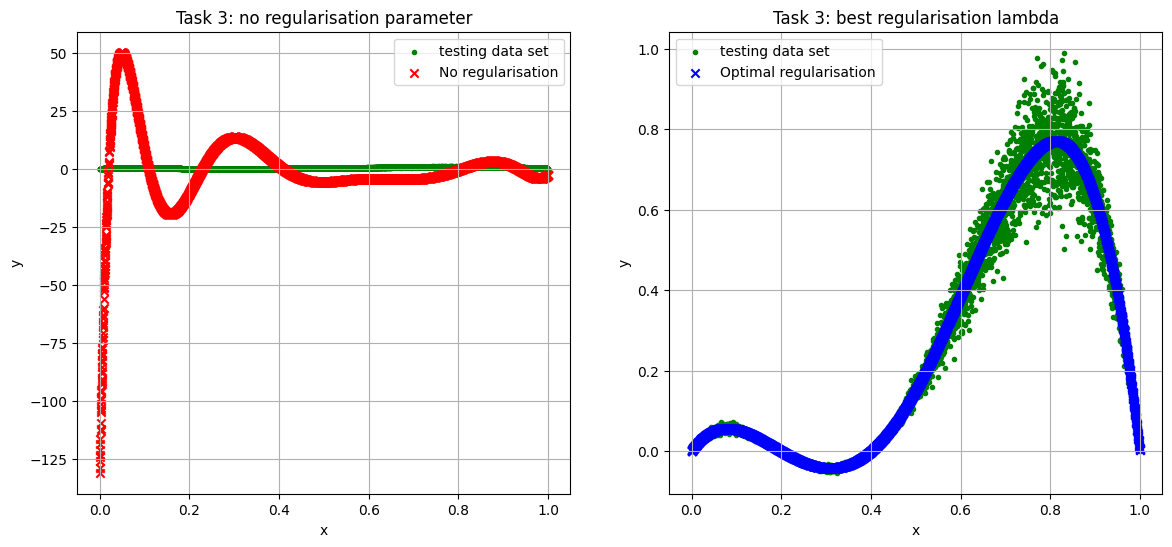

In [ ]:
optimal_lambda = lambdas[np.argmin(eout)]
print(f"Optimal lambda: {optimal_lambda}")

X_trans = transPoly(X_Task3,50)
X_train, X_test, y_train, y_test = train_test_split(X_trans, y_Task3, train_size=0.5, random_state =5)

w_no_reg = weights_reg(X_train, y_train, 0)
eout_no_reg = calc_error(w_no_reg,X_test,y_test)
y_pred_no_reg = linreg_predict(w_no_reg, X_test)

optimal_weights = weights_reg(X_train, y_train, optimal_lambda)
eout_optimal = calc_error(optimal_weights,X_test,y_test)
y_pred_optimal = linreg_predict(optimal_weights, X_test)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.set_title(f'Task 3: no regularisation parameter')
ax1.scatter(X_test[:,0], y_test, c='green', marker='.', label="testing data set")
ax1.scatter(X_test[:,0], y_pred_no_reg, c='red', marker='x', label="No regularisation")
ax1.legend(loc="best")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.grid()

ax2.set_title(f'Task 3: best regularisation lambda')
ax2.scatter(X_test[:,0], y_test, c='green', marker='.', label="testing data set")
ax2.scatter(X_test[:,0], y_pred_optimal, c='blue', marker='x', label="Optimal regularisation")
ax2.legend(loc="best")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.grid()


print(f"Error with no regularisation: {eout_no_reg}")
print(f"Error with optimal regularisation: {eout_optimal}")

### 5. Provide the following plots:
    - A plot showing model performance vs l on the domain [0,1]
    - A plot with three sub-plots containing an overfitted model, a model with the optimal l, and an underfitted model. In each plot, you should plot the data points in addition to the final hypothesis. Choose values for l that clearly demonstrate over- and underfitting.

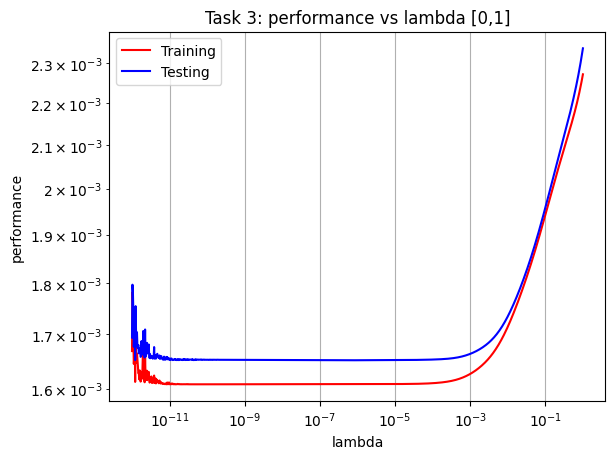

In [ ]:
plt.figure()
plt.title("Task 3: performance vs lambda [0,1]")

plt.xlabel("lambda")
plt.ylabel("performance")

lambdas_for_plotting = np.array(lambdas)

plt.plot(lambdas, ein, c='red', label="Training")
plt.plot(lambdas, eout, c='blue', label="Testing")
plt.legend(loc="best")
plt.yscale("log")
plt.xscale("log")
plt.grid()

Error of overfitted model: 242.3733765732253, lambda: 1e-15
Error of optimal model: 0.0016312763832485007, lambda: 2.406475150015422e-07
Error of underfitted model: 0.012005304292777708, lambda: 100


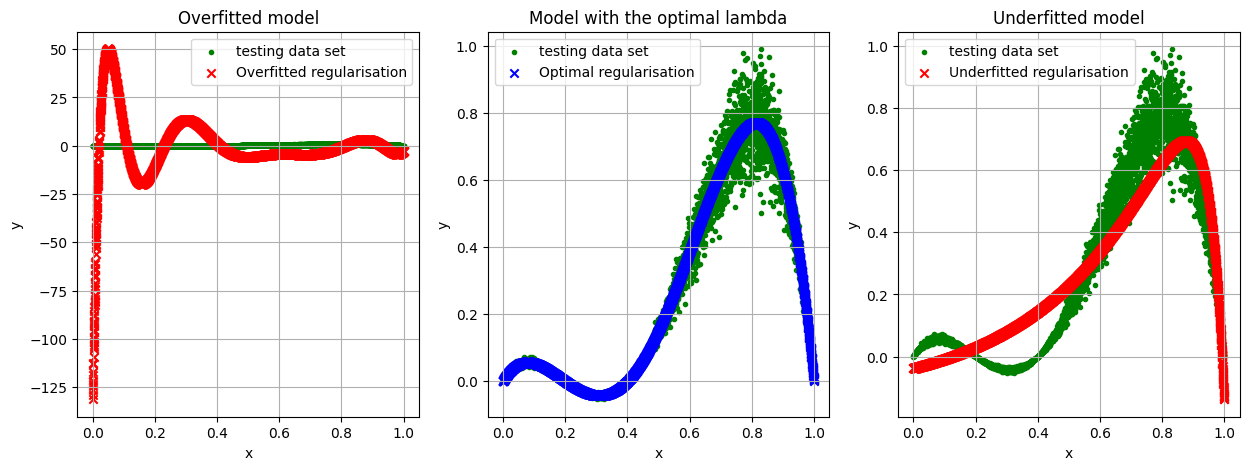

In [ ]:
overfitted_lamba = 1e-15
w_overfitted = weights_reg(X_train, y_train, overfitted_lamba)
eout_overfitted = calc_error(w_overfitted, X_test, y_test)
y_pred_overfitted = linreg_predict(w_overfitted, X_test)

underfitted_lamba = 100
w_underfitted = weights_reg(X_train, y_train, underfitted_lamba)
eout_underfitted = calc_error(w_underfitted, X_test, y_test)
y_pred_underfitted = linreg_predict(w_underfitted, X_test)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.set_title(f'Overfitted model')
ax1.scatter(X_test[:,0], y_test, c='green', marker='.', label="testing data set")
ax1.scatter(X_test[:,0], y_pred_overfitted, c='red', marker='x', label="Overfitted regularisation")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend(loc="best")
ax1.grid()

ax2.set_title(f'Model with the optimal lambda')
ax2.scatter(X_test[:,0], y_test, c='green', marker='.', label="testing data set")
ax2.scatter(X_test[:,0], y_pred_optimal, c='blue', marker='x', label="Optimal regularisation")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend(loc="best")
ax2.grid()

ax3.set_title(f'Underfitted model')
ax3.scatter(X_test[:,0], y_test, c='green', marker='.', label="testing data set")
ax3.scatter(X_test[:,0], y_pred_underfitted, c='red', marker='x', label="Underfitted regularisation")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.legend(loc="best")
ax3.grid()

print(f"Error of overfitted model: {eout_overfitted}, lambda: {overfitted_lamba}")
print(f"Error of optimal model: {eout_optimal}, lambda: {optimal_lambda}")
print(f"Error of underfitted model: {eout_underfitted}, lambda: {underfitted_lamba}")

### 6. Answer the following questions (100 words max for each answer):
    
    
<b>1. Interpret the information in the requested figures under point 5.</b>

The lambda exploration against the performance showed that the optimal value was $0.00000024$. Values lower than that start to overfit. That's what we see in the plot, with a value of $1 \times 10^-15$ (the hypothesis is very wiggly). As the lambda plots showed, the optimal value is a good match for the data. Just as Occam Razor states it, the simplest model that currently fits the data set is the best model. And lastly, in the third plot, with a lambda equal to 100, we see that a model that is too simple is just not the right model. 

<b>2. Explain the strategy chosen to decide on the optimum amount of regularisation. In your answer discuss how you refined the hyper parameter search space while looking for the optimal l.</b>

I used a logarithmic space to search for the lambda component, since after an initial test over the data (using example values that Prof. Abu used in video 12), it became evident that the 'closer' to zero, it appeared that the better the lambda was. So I needed to make sure how close was close enough. It was a question of magnitudes, as zero certainly couldn't be the right value. 

<b>3. Explain the effect of the term l*np.identity(m.shape[0]) in the pseudo-inverse.</b>

I would like to talk about this effect from the augmented error formula ($E_{aug} = E_{in} + \lambda w^T w$). This term ($\lambda w^T w$) is introduced when we use L2 regularisation. It is what help us control the weights and keep them small. If we see the regularised weights formula ($w_{reg} = (X^TX + \lambda I)^{-1} Z^T y$), one can notice that the term $\lambda I$ it improves numerical stability by ensuring the matrix is invertible even when $X^TX$ is ill-conditioned. This is why when we use no reguralisation our error is huge. There's no brakes.

# Task 4
## Task 4 Instructions

Update the code-snippet from Task 3 to perform the same analysis using K-fold cross-validation. 
1. Use Scikitlearn’s KFOLD for this and think carefully about the parameters you use in KFOLD.
2. Select the l that yields the lowest Eval and compare to the Eout obtained without regularization
3. Provide the following plots:
   - A plot showing model performance vs l on the domain [0,1]
   - A plot with three sub-plots containing an overfitted model, a model with the optimal l, and an underfitted model. In each plot, you should plot the data points in addition to the final hypothesis. Choose values for l that clearly demonstrate over- and underfitting.
4. Explain the procedure followed by using KFOLDS and discuss the main benefit and disadvantage as compared to the approach followed in task 3 (max 300 words).

## Task 4 Answer
### 1. Use Scikitlearn’s KFOLD for this and think carefully about the parameters you use in KFOLD.

(10000,)
(10000,)


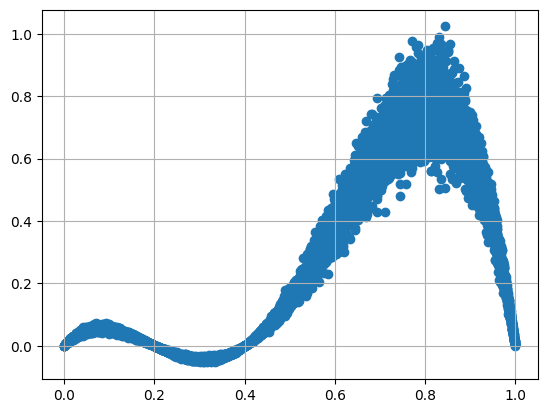

In [ ]:
data_task4 = np.loadtxt("Et2_Task3.csv", delimiter=",")
X_Task4 = data_task4[:,0]
y_Task4 = data_task4[:,1]

print(np.shape(X_Task4))
print(np.shape(y_Task4))
plt.scatter(X_Task4, y_Task4)
plt.grid()

(10000, 50) (10000,)


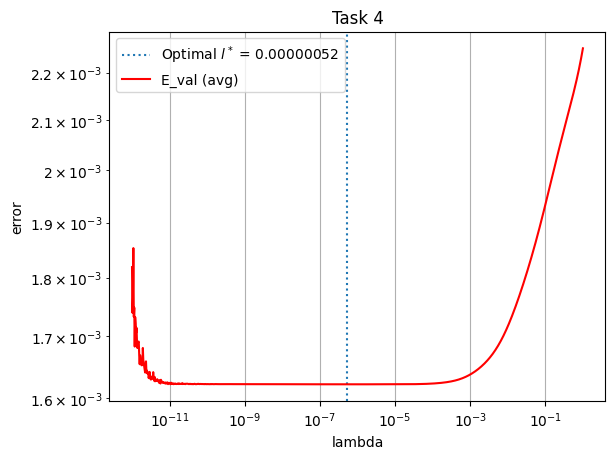

In [280]:
"""
Skit learn default K is 3 or 5 (depending on version)

rule of thumb
K = N/5

And Abu recommends:
K = N/10
"""

X_trans_Task4 = transPoly(X_Task4, 50)

# before applying k-fold cross validation, 
# we can split the data into training and testing sets to evaluate 
# the performance of our model on unseen data after we have found the optimal 
# lambda using cross validation on the training set.
#  This way, we can get an estimate of how well our model generalizes to new data.
X_train, X_test, y_train, y_test = train_test_split(X_trans_Task4, y_Task4, train_size=0.7, random_state =5)

"""
The shuffle=True option randomizes the order of the data points,
and the random_state=0 ensures that this shuffling is consistent across multiple runs.
"""
k_fold_cross_validator= KFold(n_splits=10, shuffle=True, random_state=0)
 
print(np.shape(X_trans_Task4),np.shape(y_Task4))

# don't use zero
# L2 Ridge regularisation
# Generate 1000 points logarithmically spaced from 10^-12 to 10^0 (1.0)
lambdas = np.logspace(-12, 0, 1000)

# the index will be the k-fold and the content will be sum of E_val for each lambda
e_val_container = np.zeros(len(lambdas))

for i, (train_index, val_index) in enumerate(k_fold_cross_validator.split(X_trans_Task4)):
 
    X_train = []
    for element in train_index:
        X_train.append(X_trans_Task4[element])
    X_train = np.array(X_train)
 
    y_train = []
    for element in train_index:
        y_train.append(y_Task4[element])
    y_train = np.array(y_train)
 
    X_val = []
    for element in val_index:
        X_val.append(X_trans_Task4[element])
    X_val = np.array(X_val)
 
    y_val = []
    for element in val_index:
        y_val.append(y_Task4[element])
    y_val = np.array(y_val)
    
    
    e_val = []
    for j, l in enumerate(lambdas):
        w = weights_reg(X_train,y_train,l)
        # adds the E_val to the index for each lambda
        e_val_container[j] = e_val_container[j] + calc_error(w,X_val,y_val)

        e_val.append(calc_error(w,X_val,y_val))


avg_e_val_per_lambda = []
#e_val \approx e_out (if I avg them)
for e_val in e_val_container:
    avg_e_val_per_lambda.append(e_val / k_fold_cross_validator.get_n_splits())

optimal_lambda = lambdas[np.argmin(avg_e_val_per_lambda)]
plt.axvline(x=optimal_lambda, linestyle=':', label=f'Optimal $l^*$ = {optimal_lambda:.8f}')
plt.plot(lambdas, avg_e_val_per_lambda, c='red', label='E_val (avg)')
plt.legend(loc="best")
plt.title("Task 4")
plt.xlabel("lambda")
plt.ylabel("error")
plt.yscale("log")
plt.xscale("log")
plt.grid()
plt.show() 

### 2. Select the l that yields the lowest Eval and compare to the Eout obtained without regularization

Optimal lambda: 5.220567527846975e-07
Error with no regularisation: 2.9801446065569763
Error with optimal regularisation: 0.0016296306213370035


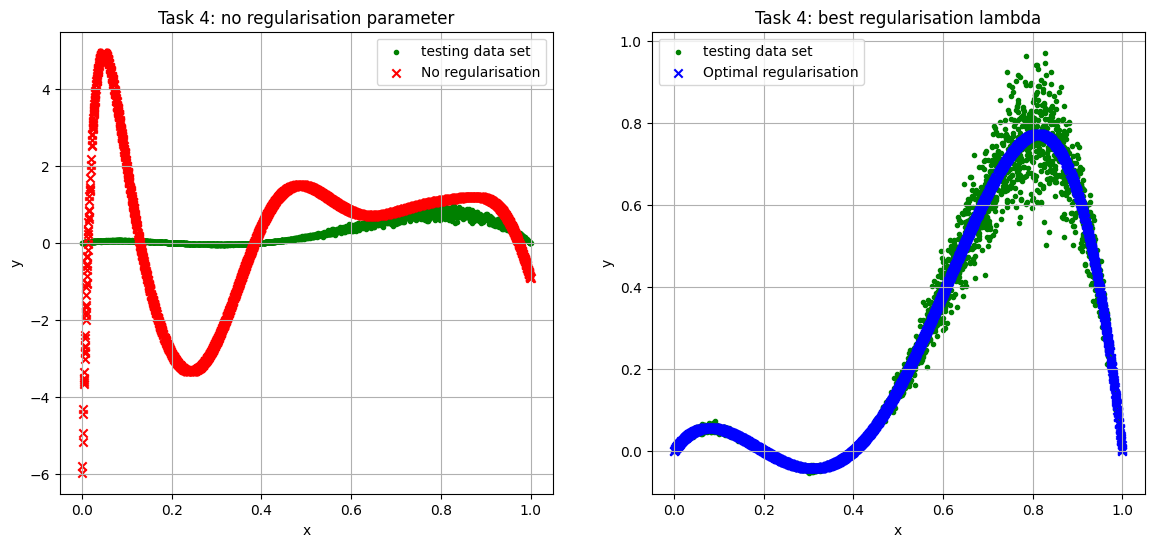

In [ ]:
optimal_lambda = lambdas[np.argmin(avg_e_val_per_lambda)]
print(f"Optimal lambda: {optimal_lambda}")


X_train, X_test, y_train, y_test = train_test_split(X_trans_Task4, y_Task4, train_size=0.7, random_state =5)

w_no_reg = weights_reg(X_train, y_train, 0)
eout_no_reg = calc_error(w_no_reg,X_test,y_test)
y_pred_no_reg = linreg_predict(w_no_reg, X_test)

optimal_weights = weights_reg(X_train, y_train, optimal_lambda)
eout_optimal = calc_error(optimal_weights,X_test,y_test)
y_pred_optimal = linreg_predict(optimal_weights, X_test)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.set_title(f'Task 4: no regularisation parameter')
ax1.scatter(X_test[:,0], y_test, c='green', marker='.', label="testing data set")
ax1.scatter(X_test[:,0], y_pred_no_reg, c='red', marker='x', label="No regularisation")
ax1.legend(loc="best")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.grid()

ax2.set_title(f'Task 4: best regularisation lambda')
ax2.scatter(X_test[:,0], y_test, c='green', marker='.', label="testing data set")
ax2.scatter(X_test[:,0], y_pred_optimal, c='blue', marker='x', label="Optimal regularisation")
ax2.legend(loc="best")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.grid()


print(f"Error with no regularisation: {eout_no_reg}")
print(f"Error with optimal regularisation: {eout_optimal}")

### 3. Provide the following plots:
- A plot showing model performance vs l on the domain [0,1]
- A plot with three sub-plots containing an overfitted model, a model with the optimal l, and an underfitted model. In each plot, you should plot the data points in addition to the final hypothesis. Choose values for l that clearly demonstrate over- and underfitting.

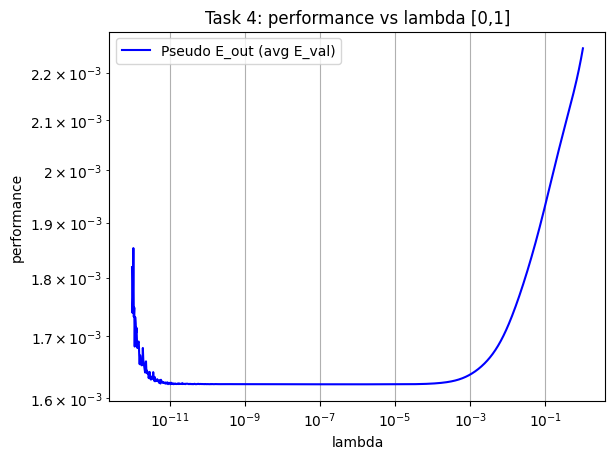

In [282]:
plt.figure()
plt.title("Task 4: performance vs lambda [0,1]")

plt.ylabel("performance")
plt.xlabel("lambda")
plt.yscale("log")
plt.xscale("log")

lambdas_for_plotting = np.array(lambdas)

plt.plot(lambdas_for_plotting, np.array(avg_e_val_per_lambda), c='blue', label="Pseudo E_out (avg E_val)")
plt.legend(loc="best")
plt.grid()


Error of overfitted model: 2.9801446065569763, lambda: 1e-18
Error of optimal model: 0.0016296306213370035, lambda: 5.220567527846975e-07
Error of underfitted model: 0.010559842553142823, lambda: 100


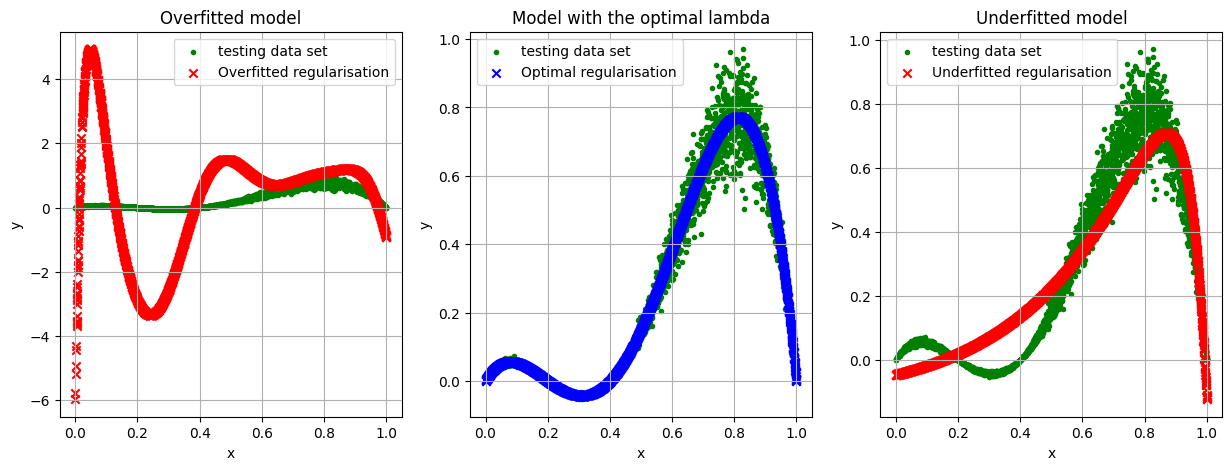

In [ ]:
overfitted_lamba = 0.000000000000000001
w_overfitted = weights_reg(X_train, y_train, overfitted_lamba)
eout_overfitted = calc_error(w_overfitted, X_test, y_test)
y_pred_overfitted = linreg_predict(w_overfitted, X_test)

underfitted_lamba = 100
w_underfitted = weights_reg(X_train, y_train, underfitted_lamba)
eout_underfitted = calc_error(w_underfitted, X_test, y_test)
y_pred_underfitted = linreg_predict(w_underfitted, X_test)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.set_title(f'Overfitted model')
ax1.scatter(X_test[:,0], y_test, c='green', marker='.', label="testing data set")
ax1.scatter(X_test[:,0], y_pred_overfitted, c='red', marker='x', label="Overfitted regularisation")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend(loc="best")
ax1.grid()

ax2.set_title(f'Model with the optimal lambda')
ax2.scatter(X_test[:,0], y_test, c='green', marker='.', label="testing data set")
ax2.scatter(X_test[:,0], y_pred_optimal, c='blue', marker='x', label="Optimal regularisation")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend(loc="best")
ax2.grid()

ax3.set_title(f'Underfitted model')
ax3.scatter(X_test[:,0], y_test, c='green', marker='.', label="testing data set")
ax3.scatter(X_test[:,0], y_pred_underfitted, c='red', marker='x', label="Underfitted regularisation")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.legend(loc="best")
ax3.grid()

print(f"Error of overfitted model: {eout_overfitted}, lambda: {overfitted_lamba}")
print(f"Error of optimal model: {eout_optimal}, lambda: {optimal_lambda}")
print(f"Error of underfitted model: {eout_underfitted}, lambda: {underfitted_lamba}")

### 4.Explain the procedure followed by using KFOLDS and discuss the main benefit and disadvantage as compared to the approach followed in task 3 (max 300 words).

Something that I thought was crucial was to leave a portion of the data untouched. So I first transformed x (to elevate the polynomial to the 50th order). Then I split the test and training data, I left the testing data out of the picture to perform the kfolds over the training data (where it splits into training and validation data). And once I had summed and averaged all the $E_{val}$ values found I mapped that to the best lambda across all the lambdas and all the folds. 

This approach is very thorough but very costly. Basically, 'all' data is fully used for training and fully used for validation. With K=10, I manage to have a balance between a high K that makes $E_{val}$ a good estimate of $E_{out}$ and a K small so that N is big enough to choose the best regularisation parameter. But this means training the model 10 times. When this is combined with the fact that we are also looping through an array of lambdas is not unexpected to say that the process also takes around four times more to complete in my computer (9.3 seconds vs 40.3 seconds).

# Reflection
<b>1. In the Reflection part of the notebook, clearly describe the changes you have made based on your peers' work and feedback (100 words max).</b>

Sara pointed out that I could simplify my cells for task 1. Lori helped me fixed some labels in task 3 that I labelled mistakenly. Reviewing Dermot's notebook helped me see that my assumptions about task 2 were wrong (I data snooped to try and reduce my power range), thanks to his notebook I improved my methodology greatly. It also helped me improve some of my plots, adding some extra elements. Ismael mentioned that my kfold cell was a bit wasteful and there was better ways to get the $E_{vals}$, this feedback came a bit late, I didn't change it.

<b>2. Summarise your understanding of (100 words max for each):</b>

<b>1. how regularisation (as discussed in this E-tivity) impacts the complexity of a model.</b>

Reguralisation is a constrain over the weights. It is a soft constraint because it doesn't hardly sets weights over a certain order to go always to zero but despite not excluding any orders, it makes it 'harder' for the model to play around with all the powers. So it isn't reducing the VC dimension outright, but it reduces the complexity of the model by forcing the its effort in weights of a certain order. That's why we say that regularisation acts as "the brakes" on learning, because it discourages overly complex models making adjustments at weight level.

<b>2. how complexity impacts the data requirements to successfully train a machine learning model.</b> 

Small data sets can't afford complex models. Occam's razor says that if I simpler model can do it, a more complex model is not needed. But this won't always be the case.

<b>3. how cross validation can help in finding suitable hyper parameters</b>

Hyperparameters are not learned from data directly, they must be chosen. One can be guided by theory, but regardless of how much thought goes into them, one can end up with poorly selected values. Cross-validation help us tune them in a principled way. By splitting training data into validation and training folds, we get K $E_{vals}$ that are biased, but still a proxy to $E_{outs}$. By averaging them and because they work within the tuning space, we can use them. Completed the search, we train and then finally test our model, when we double-check if the found values are suitable. 

